In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45, Heun

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

/mnt/home/zwan1/venvs/nqs_bridge_sampling/lib/python3.11/site-packages/netket/graph/common_lattices.py:126: InitializePeriodicLatticeOnSmallLatticeWarning: 
You are attempting to define a lattice with length 2 in dimension 1 using periodic boundary condition.

Lattice with less than two sites in one direction does not support periodic boundary condition.
The behavior of the lattice is equivalent to an open boundary condition in this direction.

To avoid this warning, consider either using a lattice with more than two sites in the direction you want to be periodic,
or define the graph using :class:`~netket.graph.Graph` by adding the edges manually.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.InitializePeriodicLatticeOnSmallLatticeWarning.html
or the list of all common errors and warnings at
	 https://netket.readthedocs.io/en/latest/api/err

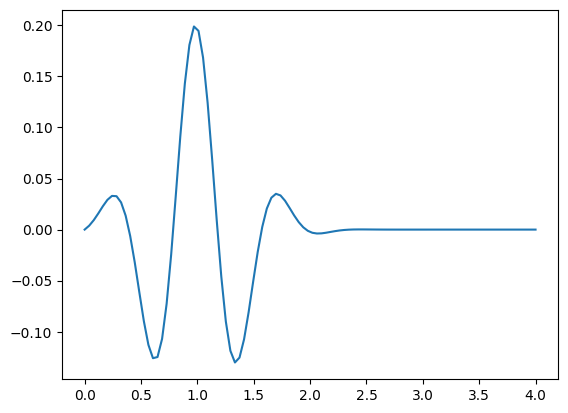

170
loaded parameters


In [ ]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
from functools import partial
from flax import serialization

Lx = 8
Ly = 2
N = Lx * Ly
A_p=0.10

hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=0)

graph = nk.graph.Grid((Lx, Ly), pbc=(True, False))
graph_pbc = nk.graph.Grid((Lx, Ly), pbc=(True, True))
hamiltonian = nk.operator.Heisenberg(hilbert, graph, J=1., sign_rule=True)


def pulse(t, A_p, omega_p, sigma_p, t_p):
    return A_p * jnp.sin(omega_p * t) * jnp.exp(-((t - t_p) ** 2) / (2 * sigma_p**2))

pulse_partial = partial(pulse, A_p=A_p, omega_p=8.0, sigma_p=0.4, t_p=0.987)

t = jnp.linspace(0, 4, 100)
plt.plot(t, partial(pulse, A_p=0.20, omega_p=8.0, sigma_p=0.4, t_p=0.987)(t))
plt.show()

def grid_translation_generators(Lx, Ly):
    N = Lx * Ly
    def idx(x, y): return x + Lx*y

    # translation by +1 in x
    tx = np.empty(N, dtype=int)
    for x in range(Lx):
        for y in range(Ly):
            tx[idx(x,y)] = idx((x+1)%Lx, y)

    # translation by +1 in y
    ty = np.empty(N, dtype=int)
    for x in range(Lx):
        for y in range(Ly):
            ty[idx(x,y)] = idx(x, (y+1)%Ly)

    return [tx, ty]


def get_vstate(n_samples):
    sampler = nk.sampler.MetropolisExchange(hilbert, graph=graph, n_chains=n_samples)
    # use the pbc graph translation_group for the rbm symmetry: x-translation + y reflection.
    model = nk.models.RBMSymm(
            symmetries=graph_pbc.translation_group(), alpha=10, param_dtype=complex, use_visible_bias=False
        )
    return nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )


def get_vstate_parameters(n_samples):
    vstate = get_vstate(n_samples)

    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    e0 = nk.exact.lanczos_ed(hamiltonian)
    print(e0)
    gs = nk.driver.VMC_SR(
        hamiltonian,
        optimizer=nk.optimizer.Sgd(0.005),
        variational_state=vstate,
        diag_shift=1e-4,
    )
    gs.run(1000, callback=lambda s, l, d: d._loss_stats.mean > e0 - 10)
    return vstate.parameters


vstate = get_vstate(2**13)
print(vstate.n_parameters)
if not os.path.exists("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack"):
    parameters = get_vstate_parameters(2**12)
    binary_data = serialization.to_bytes(parameters)
    with open("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack", "wb") as outfile:
        outfile.write(binary_data)
    print("saved parameters")
else:
    with open("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack", "rb") as infile:
        binary_data = infile.read()
        parameters = serialization.from_bytes(vstate.parameters, binary_data)
    print("loaded parameters")
vstate.parameters = parameters.copy()

e0 = nk.exact.lanczos_ed(hamiltonian)
estimated_e = vstate.expect(hamiltonian)
print(f"GS energy {e0}")
print(f"variational energy {estimated_e}")

In [ ]:

# def get_vstate_parameters(n_samples):
#     vstate = get_vstate(n_samples)
#     print(vstate.n_parameters)
#     if not os.path.exists("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack"):
#         parameters = get_vstate_parameters(2**12)
#         binary_data = serialization.to_bytes(parameters)
#         with open("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack", "wb") as outfile:
#             outfile.write(binary_data)
#         print("saved parameters")
#     else:
#         with open("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack", "rb") as infile:
#             binary_data = infile.read()
#             parameters = serialization.from_bytes(vstate.parameters, binary_data)
#         print("loaded parameters")
#     vstate.parameters = parameters.copy()

#     # Thermalize
#     for i in range(100):
#         vstate.sample(n_samples=n_samples)
#     e0 = nk.exact.lanczos_ed(hamiltonian)
#     print(e0)
#     gs = nk.driver.VMC_SR(
#         hamiltonian,
#         optimizer=nk.optimizer.Sgd(0.01),
#         variational_state=vstate,
#         diag_shift=1e-6,
#     )
#     gs.run(200, callback=lambda s, l, d: d._loss_stats.mean > e0 - 10)
#     return vstate.parameters
# parameters = get_vstate_parameters(2**15)
# binary_data = serialization.to_bytes(parameters)
# with open("./data" + f"/rbmsymm_params_heisenberg_{Lx}_{Ly}.mpack", "wb") as outfile:
#     outfile.write(binary_data)
# print("saved parameters")

170
loaded parameters


KeyboardInterrupt: 

[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)]


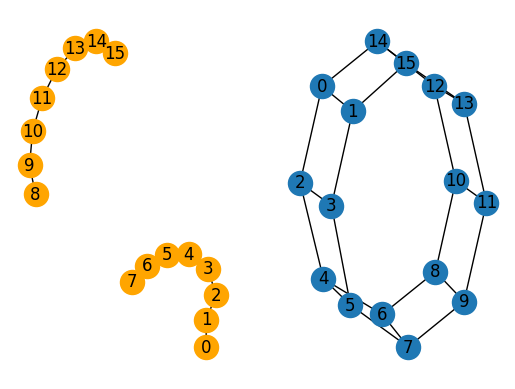

In [4]:
x_bonds = []
for y in range(Ly):
    for x in range(Lx - 1):
        i = y * Lx + x
        j = y * Lx + (x + 1)
        x_bonds.append((i, j))
print(x_bonds)
x_bonds_graph = nk.graph.Graph(edges=x_bonds)
H = graph.to_networkx()
G = x_bonds_graph.to_networkx()
import networkx as nx
fig, (axs0,axs1) = plt.subplots(1,2)
nx.draw(G, node_color='orange', ax=axs0,with_labels=True)
nx.draw(H, ax=axs1,with_labels=True)
heisenberg_x = nk.operator.Heisenberg(hilbert,  x_bonds_graph, J=1.)
quench_hamiltonian = lambda t: hamiltonian + pulse_partial(t) * heisenberg_x
s_correlator = nk.operator.Heisenberg(hilbert, x_bonds_graph, J=1./N)

fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("s_corr", "Mean"),
    ("s_corr", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_corr(step, log, driver):
    log['s_corr'] = driver.state.expect(s_correlator)
    return True

# Exact dynamics

/mnt/home/zwan1/venvs/nqs_bridge_sampling/lib/python3.11/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/mnt/home/zwan1/venvs/nqs_bridge_sampling/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


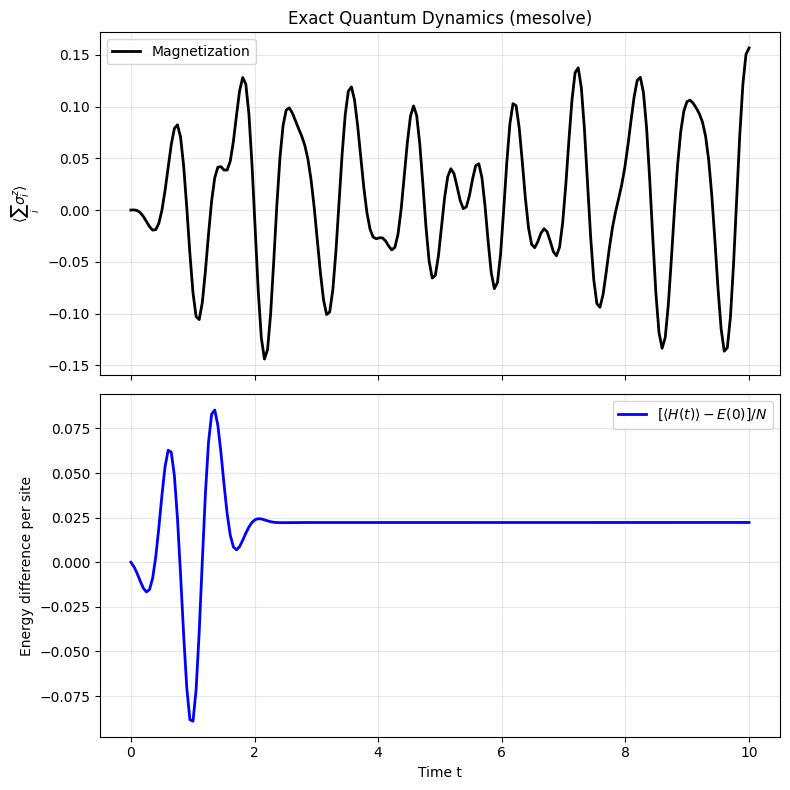

In [5]:
import qutip as qt

# Define the time-dependent Hamiltonian for QuTiP
# H = [H0, [H1, pulse_partial]] is already defined above
H0 = hamiltonian.to_sparse()
H1 = heisenberg_x.to_sparse()
H0_qobj = qt.Qobj(H0)
H1_qobj = qt.Qobj(H1)
H_qutip = [H0_qobj, [H1_qobj, lambda t, args: float(pulse_partial(t))]]
# Get initial state from vstate
vstate = get_vstate(2**10)
vstate.parameters = parameters.copy()
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize
# Create total magnetization operator (sum of Z_i)
Scorr_qutip = qt.Qobj(s_correlator.to_sparse())
# Time evolution parameters
T = 10
times_exact = np.linspace(0.0, T, 200)
# Evolve the state using QuTiP's mesolve, only track magnetization
result = qt.mesolve(H_qutip, psi0_qutip, times_exact, [], [Scorr_qutip], options=qt.Options(store_states=True))
magnetizations_exact = result.expect[0]
# Compute the energy of the full time-dependent Hamiltonian at each time
energies_exact = []
for idx, t in enumerate(times_exact):
    psi_t = result.states[idx]
    Ht = H0_qobj + float(pulse_partial(t)) * H1_qobj
    energy = qt.expect(Ht, psi_t)
    energies_exact.append(energy)
# Compute E(0) and plot the normalized energy difference
E0 = energies_exact[0]
magnetizations_exact0 = magnetizations_exact[0]
N_sites = N
energy_diff = (np.array(energies_exact) - E0) / N_sites
magnetizations_exact_diff = np.array(magnetizations_exact) - magnetizations_exact0
# Plot the exact dynamics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax1.plot(times_exact, np.real(magnetizations_exact_diff), 'k-', linewidth=2, label='Magnetization')
ax1.set_ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
ax1.set_title('Exact Quantum Dynamics (mesolve)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(times_exact, np.real(energy_diff), 'b-', linewidth=2, label=r'$[\langle H(t) \rangle - E(0)]/N$')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Energy difference per site')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Standard Dynamics

In [6]:
import schmitt_tdvp_randomized_bridge
import importlib
importlib.reload(schmitt_tdvp_randomized_bridge)
from schmitt_tdvp_randomized_bridge import TDVPSchmittRandomizedBridge

In [ ]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_randomized_permutation_bridge import TDVPSchmittRandomizedPermutationBridge


def fit_bridge(q1, q2, n_samples_tvmc):
    T = 10
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_Ap_{A_p:1.2f}_q1_{q1:1.2f}_q2_{q2:1.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/HEISENBERG_LADDER_{Lx}_{Ly}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    vstate = get_vstate(n_samples_tvmc)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
            logger.restore_state(vstate)
    else:
        t0 = 0.0
        dt = 1e-3
        vstate.parameters = parameters.copy()
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    
    for i in range(100):
        vstate.sample()
    callbacks = []
    callbacks.append(measure_corr)
    if q1 + q2 == 0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    
    dt = 0.001
    # integrator = RK45(dt, adaptive=False, rtol=1e-6, dt_limits=(1e-5, 1e-2))
    integrator = Heun(dt)
    tvmc_kwargs = {}
    if q1 + q2 == 0:
        driver = TDVPSchmitt(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=t0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-6,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittRandomizedPermutationBridge(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q_hamiltonian=q1,
            q_permutation=q2,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-8,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    driver.run(
        T-t0,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)
fit_bridge(0.45, 0.45, 2**13)

  0%|          | 0.00/10.0 [00:00<?, ?it/s]

Restored: True
Restored: True
Restored: True
Restored: True


/tmp/ipykernel_2240558/3663910274.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_en.plot(times_exact, energy_diff, "k-", linewidth=1, label="ED", linestyle="dashed")
/tmp/ipykernel_2240558/3663910274.py:59: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_corr.plot(


(-0.25, 0.25)

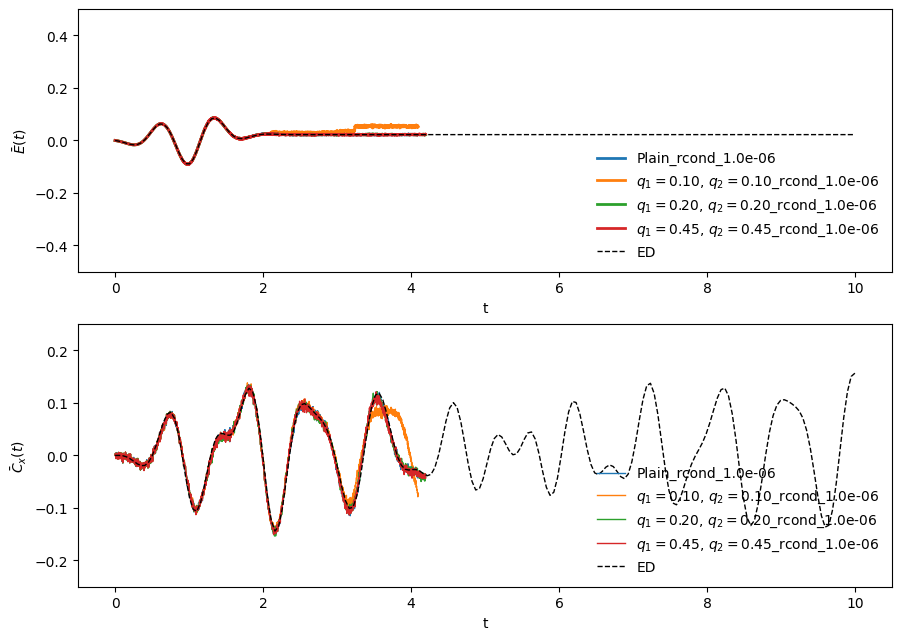

In [47]:
fig, (ax_en, ax_corr) = plt.subplots(2, 1, figsize=(7*1.5, 5*1.5))
n_samples = 2**14
discard = 50
for q1, q2, rcond in [
                      # (0,0,1e-8),
                      # (0,0,1e-7),
                      (0,0,1e-6), 
                    #   (0.1, 0.8, 1e-8), 
                    #   (0.25, 0.5, 1e-8), 
                      (0.1, 0.1, 1e-6), 
                      # (0.1, 0.1, 1e-7),
                      # (0.1, 0.1, 1e-8),
                      # (0.5, 0.0, 1e-6),
                      # (0.5, 0.0, 1e-7),
                      # (0.9, 0.0, 1e-7),
                      # (0.9, 0.0, 1e-8),
                      # (0.5, 0.0, 1e-8),
                      # (0.2, 0.2, 1e-7),
                      # (0.2, 0.2, 1e-8),
                      (0.2, 0.2, 1e-6),
                    #   (0.5, 0.25, 1e-8),
                      # (0.4,0.4,1e-7),
                    #   (0.45, 0.45, 1e-10),
                      # (0.45, 0.45, 1e-7),
                      # (0.45, 0.45, 1e-8),
                      (0.45, 0.45, 1e-6),
                      # (0.45, 0.45, 1e-5),
                      # (0.45, 0.45, 1e-4),
                      # (0.45, 0.45, 1e-3),
                      # (0.45, 0.45, 1e-99),
                    #   (0.49, 0.49, 1e-8)
                      ][:]:
    label = f"Plain_rcond_{rcond:1.1e}" if q1 + q2 == 0 else f"$q_1=${q1:1.2f}, $q_2=${q2:1.2f}_rcond_{rcond:1.1e}"
    exp_name = f"bridge_{n_samples}_Ap_{A_p:1.2f}_q1_{q1:1.2f}_q2_{q2:1.2f}_rcond_{rcond:1.1e}_discard_{discard}"
    save_path = f"./data/HEISENBERG_LADDER_{Lx}_{Ly}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    restored = logger.restore()
    print("Restored:", restored)
    if not restored:
        continue
    xval = logger.data["t"]["values"]

    # Energy
    yval = np.array(logger.data["Generator"]["Mean"])
    yval_diff = yval - yval[0]
    ax_en.plot(xval[: len(yval_diff)], yval_diff / N, label=label, zorder=-1,lw=2)

    yval = np.array(logger.data["s_corr"]["Mean"])
    yval_diff = yval - yval[0]
    ax_corr.plot(xval, yval_diff, label=label, zorder=-1,lw=1)


ax_en.plot(times_exact, energy_diff, "k-", linewidth=1, label="ED", linestyle="dashed")
ax_en.set_xlabel("t")
ax_en.set_ylabel(r"$\bar E(t)$")
ax_en.set_ylim([-0.5,0.5])
ax_en.legend(frameon=False)

ax_corr.plot(
    times_exact,
    magnetizations_exact_diff,
    "k-",
    linewidth=1,
    label="ED",
    linestyle="dashed",
)

ax_corr.set_xlabel("t")
ax_corr.set_ylabel(r"$\bar C_x(t)$")
ax_corr.legend(frameon=False)
ax_corr.set_ylim([-0.25,0.25])

File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


/tmp/ipykernel_2218317/2204072951.py:43: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_en.plot(times_exact, energy_diff, "k-", linewidth=1, label="ED", linestyle="dashed")
/tmp/ipykernel_2218317/2204072951.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_corr.plot(


(-0.5, 0.5)

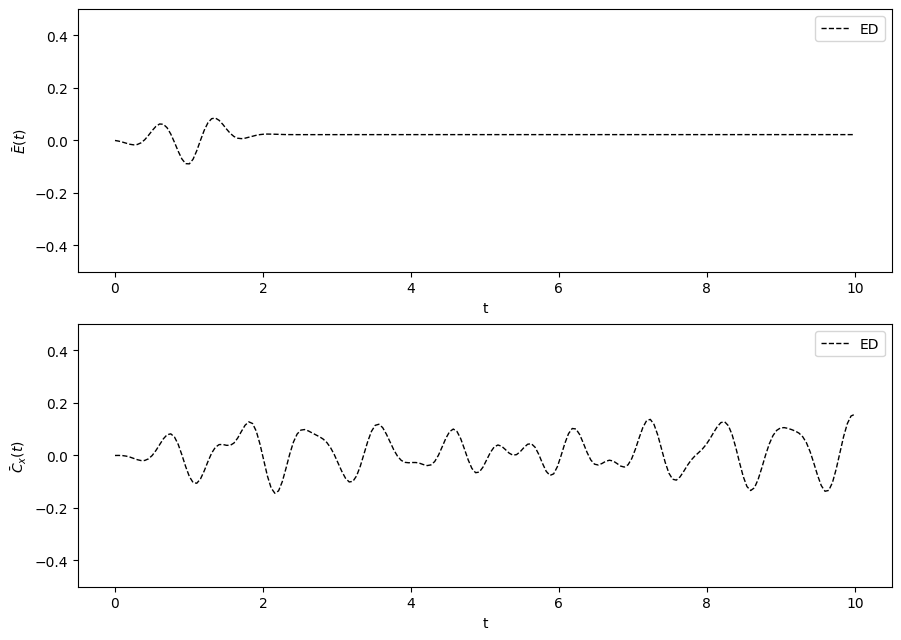

In [192]:
fig, (ax_en, ax_corr) = plt.subplots(2, 1, figsize=(7*1.5, 5*1.5))
n_samples = 2**16

for q1, q2, rcond in [
                        (0,0,1e-8),
                        (0.4,0.0,1e-8),
                      (0,0,1e-7),
                      # (0,0,1e-6),
                    #   (0.1, 0.8, 1e-8), 
                    #   (0.25, 0.5, 1e-8), 
                    #   (0.1, 0.1, 1e-8), 
                      # (0.1, 0.1, 1e-7),
                    #   (0.2, 0.2, 1e-7),
                    #   (0.5, 0.25, 1e-8),
                    #   (0.4,0.4,1e-8),
                    #   (0.45, 0.45, 1e-10),
                      # (0.45, 0.45, 1e-7),
                    #   (0.45, 0.45, 1e-6),
                      (0.2, 0.2, 1e-8),
                      (0.45, 0.45, 1e-8),
                    #   (0.49, 0.49, 1e-8)
                      ][:]:
    label = f"Plain_rcond_{rcond:1.1e}" if q1 + q2 == 0 else f"$q_1=${q1:1.2f}, $q_2=${q2:1.2f}_rcond_{rcond:1.1e}"
    exp_name = f"bridge_{n_samples}_Ap_{A_p:1.2f}_q1_{q1:1.2f}_q2_{q2:1.2f}_rcond_{rcond:1.1e}"
    save_path = f"./data/HEISENBERG_LADDER_{Lx}_{Ly}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    restored = logger.restore()
    print("Restored:", restored)
    if not restored:
        continue
    xval = logger.data["t"]["values"]

    # Energy
    yval = np.array(logger.data["Generator"]["Mean"])
    yval_diff = yval - yval[0]
    ax_en.plot(xval[: len(yval_diff)], yval_diff / N, label=label, zorder=-1)

    yval = np.array(logger.data["s_corr"]["Mean"])
    yval_diff = yval - yval[0]
    ax_corr.plot(xval, yval_diff, label=label, zorder=-1)


ax_en.plot(times_exact, energy_diff, "k-", linewidth=1, label="ED", linestyle="dashed")
ax_en.set_xlabel("t")
ax_en.set_ylabel(r"$\bar E(t)$")
ax_en.set_ylim([-0.5,0.5])
ax_en.legend()

ax_corr.plot(
    times_exact,
    magnetizations_exact_diff,
    "k-",
    linewidth=1,
    label="ED",
    linestyle="dashed",
)
ax_corr.set_xlabel("t")
ax_corr.set_ylabel(r"$\bar C_x(t)$")
ax_corr.legend()
ax_corr.set_ylim([-0.5,0.5])

In [145]:
logger.restore()
data = logger.data